# Week 2 Assignment: Decomposition & Features
**DSE6230: Forecasting Methods and Applications**

Practice decomposing time series into Trend, Seasonal, and Residual components, and extracting features.

In [21]:
!pip install pandas numpy matplotlib statsmodels

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import MSTL, seasonal_decompose
from statsmodels.tsa.tsatools import add_trend

## Part 1: Self-Guided Exercises

### Setup
We will use the `statsmodels` library for decomposition and the airline-passengers dataset for feature extraction.

In [23]:
# Load airline data for decomposition
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
airline = pd.read_csv(url, parse_dates=['Month'], index_col='Month')
airline.index.freq = 'MS'  # Monthly start

### Exercise 1.1: Classical Decomposition (Additive vs Multiplicative)
**Instruction**: Perform a **multiplicative** decomposition on the `airline` dataset. Store the result in `decomp_mult`. Notice how the seasonal component's magnitude varies with the trend.

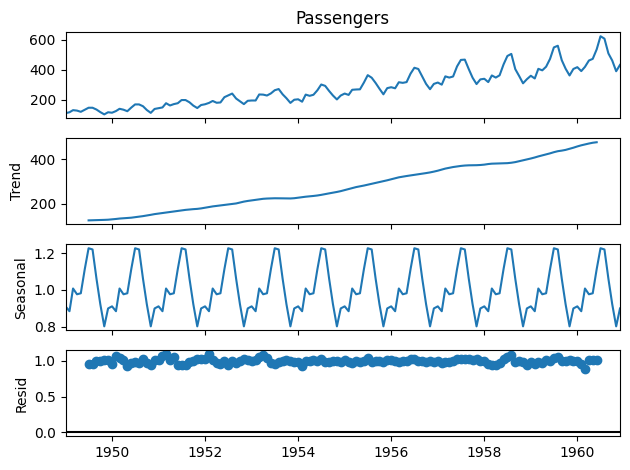

In [24]:
# Your Code Here
decomp_mult = seasonal_decompose(airline['Passengers'], model='multiplicative')
decomp_mult.plot()
plt.show()

# add manual attribute for check below
decomp_mult.model = 'multiplicative'

In [25]:
#| Check your work
try:
    assert 'decomp_mult' in locals(), "Variable 'decomp_mult' missing."
    assert decomp_mult.model == 'multiplicative', "Model should be multiplicative."
    print("Exercise 1.1 Passed!")
except Exception as e:
    print(f"Exercise 1.1 Failed: {e}")

Exercise 1.1 Passed!


### Exercise 1.2: MSTL Decomposition
**Instruction**: The `airline` data has a clear monthly seasonality (period=12). Use `MSTL` from `statsmodels` to decompose the data. Store the result in `mstl_fit`.

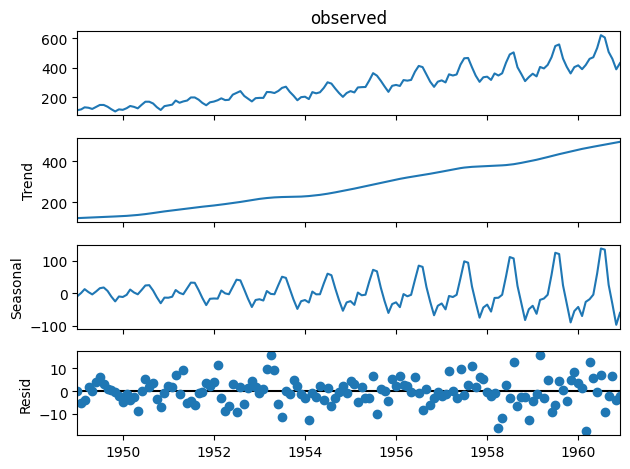

In [26]:
# Your Code Here
mstl_fit = MSTL(airline['Passengers'], periods=(12,)).fit()
mstl_fit.plot()
plt.show()

In [27]:
#| Check your work
try:
    assert 'mstl_fit' in locals(), "Variable 'mstl_fit' missing."
    assert hasattr(mstl_fit, 'seasonal'), "Result should have seasonal component."
    print("Exercise 1.2 Passed!")
except Exception as e:
    print(f"Exercise 1.2 Failed: {e}")

Exercise 1.2 Passed!


### Exercise 1.3: Feature Extraction (Strength of Trend)
**Instruction**: Calculate the "Strength of Trend" feature for the `airline` data using the `mstl_fit` result.
The formula is $F_T = \max\left(0, 1 - \frac{\text{Var}(R_t)}{\text{Var}(T_t + R_t)}\right)$, where $R_t$ is the remainder and $T_t$ is the trend.
Assign the result to `trend_strength`.

In [28]:
# Your Code Here
trend = mstl_fit.trend
resid = mstl_fit.resid
trend_strength = max(0, 1 - resid.var() / (trend + resid).var())

In [29]:
#| Check your work
try:
    assert 'trend_strength' in locals(), "Variable 'trend_strength' missing."
    assert 0 <= trend_strength <= 1, "Strength should be between 0 and 1."
    print(f"Exercise 1.3 Passed! Trend Strength: {trend_strength:.4f}")
except Exception as e:
    print(f"Exercise 1.3 Failed: {e}")

Exercise 1.3 Passed! Trend Strength: 0.9973


## Part 2: Textbook Exercises

Complete the following exercises from *Forecasting: Principles and Practice, the Pythonic Way*.

### Chapter 3: Time Series Decomposition

#### Question 3.1
> Consider the GDP information in `global_economy`. Plot the GDP per capita for each country over time. Which country has the highest GDP per capita? How has this changed over time?

#### Question 3.2
> For each of the following series, make a graph of the data. If transforming seems appropriate, do so and describe the effect: United States GDP from `global_economy`, Slaughter of Victorian "Bulls, bullocks and steers" from `aus_livestock`, Victorian Electricity Demand from `vic_elec`, and Gas production from `aus_production`.

#### Question 3.3
> Why is a Box-Cox transformation unhelpful for the `canadian_gas` data?

#### Question 3.4
> What Box-Cox transformation would you select for your retail data (from Exercise 7 in Section 2.10)?

#### Question 3.5
> For the following series, find an appropriate Box-Cox transformation to stabilise the variance: `Tobacco` from `aus_production`, `Economy` class passengers between Melbourne and Sydney from `ansett`, and `Pedestrian` counts at Southern Cross Station from `pedestrian`.

#### Question 3.6
> Consider the last five years of the Gas data from `aus_production`. Plot the time series. Use `seasonal_decompose` (multiplicative) to calculate trend-cycle and seasonal indices. Compute and plot seasonally adjusted data. Add an outlier and recompute.

#### Question 3.7
> Decompose your retail time series using the MSTL method. Does it reveal any outliers or unusual features?

#### Question 3.8
> Write about 3-5 sentences describing the results of the decomposition for the persons in the civilian labour force in Australia (Figures 3.13 and 3.14). Is the recession of 1991/1992 visible?

### Chapter 4: Time Series Features

#### Question 4.1
> Write a function to compute the mean and standard deviation of a time series and apply it to the `PBS` data. Plot the series with the highest mean and the series with the lowest standard deviation.

#### Question 4.2
> Use `sns.pairplot()` to look at the relationships between the STL-based features for the holiday series in the `tourism` data. Which is the peak quarter for holidays in each state?

#### Question 4.3
> Use a feature-based approach to look for outlying series in the `PBS` data. What is unusual about the series you identify?

In [30]:
# Question 3.1
gdp_pc = (
    pd.read_csv('sample_data/global_economy.csv')
          .assign(GDP_per_capita=lambda d: d['GDP']/d['Population'])
          .dropna(subset=['GDP_per_capita'])
          )

# Highest in the most recent year
latest = gdp_pc[gdp_pc['ds'] == gdp_pc['ds'].max()]
print(latest.nlargest(5, 'GDP_per_capita')[['unique_id', 'ds', 'GDP_per_capita']])

# Highest in any year
print(gdp_pc.nlargest(5, 'GDP_per_capita')[['unique_id', 'ds', 'GDP_per_capita']])




              unique_id    ds  GDP_per_capita
8403         Luxembourg  2017   104103.036747
8461   Macao SAR, China  2017    80892.821329
13439       Switzerland  2017    80189.696861
10491            Norway  2017    75504.566255
6083            Iceland  2017    70056.873392
          unique_id    ds  GDP_per_capita
9502         Monaco  2014   185152.527227
9496         Monaco  2008   180640.125115
8110  Liechtenstein  2014   179308.075616
8109  Liechtenstein  2013   173528.150454
9501         Monaco  2013   172588.877783


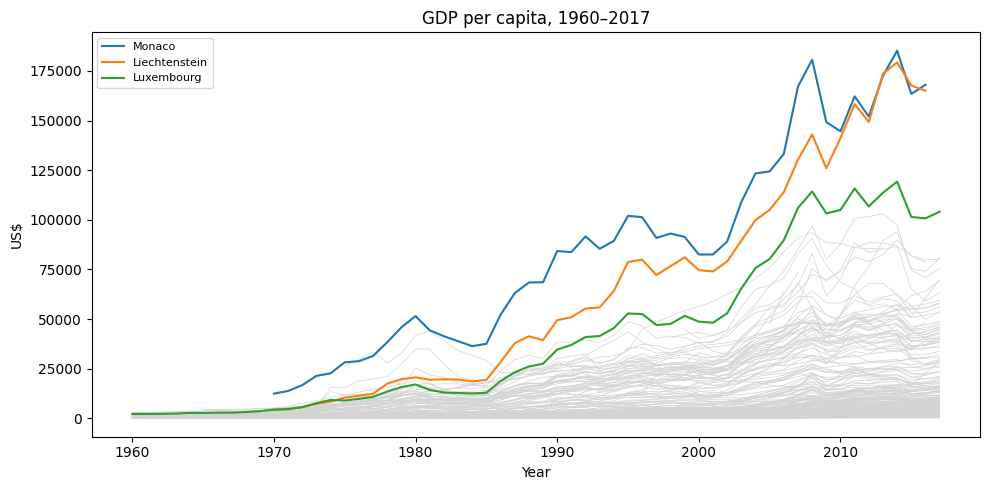

In [31]:
top = gdp_pc.nlargest(30, 'GDP_per_capita')['unique_id'].unique()[:5]

fig, ax = plt.subplots(figsize=(10, 5))

for country, grp in gdp_pc.groupby('unique_id'):
    ax.plot(grp['ds'], grp['GDP_per_capita'],
            color='lightgrey', linewidth=0.5, zorder=1)

for country in top:
    grp = gdp_pc[gdp_pc['unique_id'] == country]
    ax.plot(grp['ds'], grp['GDP_per_capita'], linewidth=1.5,
            label=country, zorder=2)

ax.legend(fontsize=8)
ax.set(title='GDP per capita, 1960–2017', xlabel='Year', ylabel='US$')
plt.tight_layout()
plt.show()

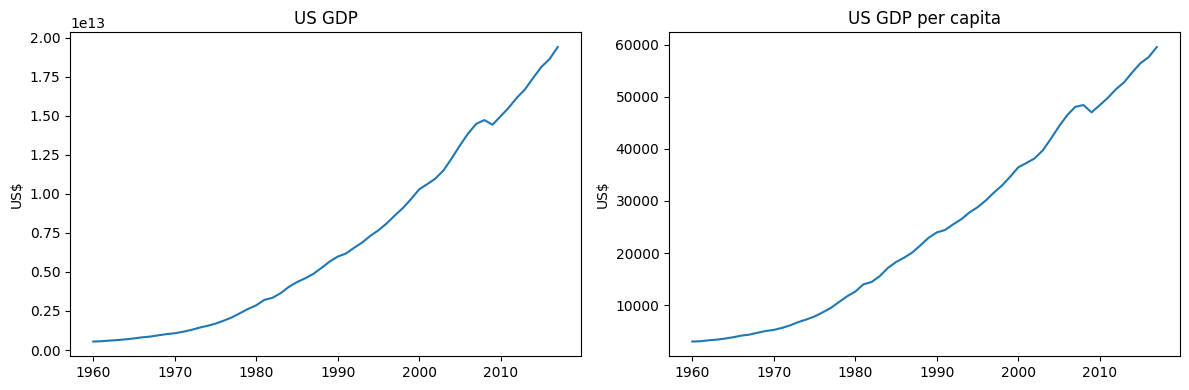

In [32]:
# Question 3.2
us_gdp = gdp_pc[gdp_pc['unique_id'] == 'United States']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(us_gdp['ds'], us_gdp['GDP'])
axes[0].set(title='US GDP', ylabel='US$')

axes[1].plot(us_gdp['ds'], us_gdp['GDP'] / us_gdp['Population'])
axes[1].set(title='US GDP per capita', ylabel='US$')
plt.tight_layout()

<Axes: title={'center': 'Slaughter — bulls, bullocks and steers, Victoria'}, xlabel='ds'>

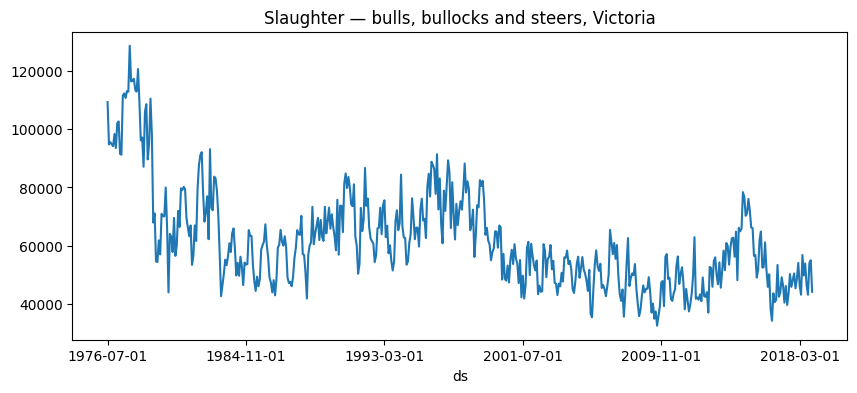

In [34]:
bull_livestock = (
        pd.read_csv('sample_data/aus_livestock.csv')
          .loc[lambda x: x['unique_id'] == 'Victoria_Bulls, bullocks and steers']
          )
bull_livestock.set_index('ds')['y'].plot(figsize=(10, 4),
    title='Slaughter — bulls, bullocks and steers, Victoria')

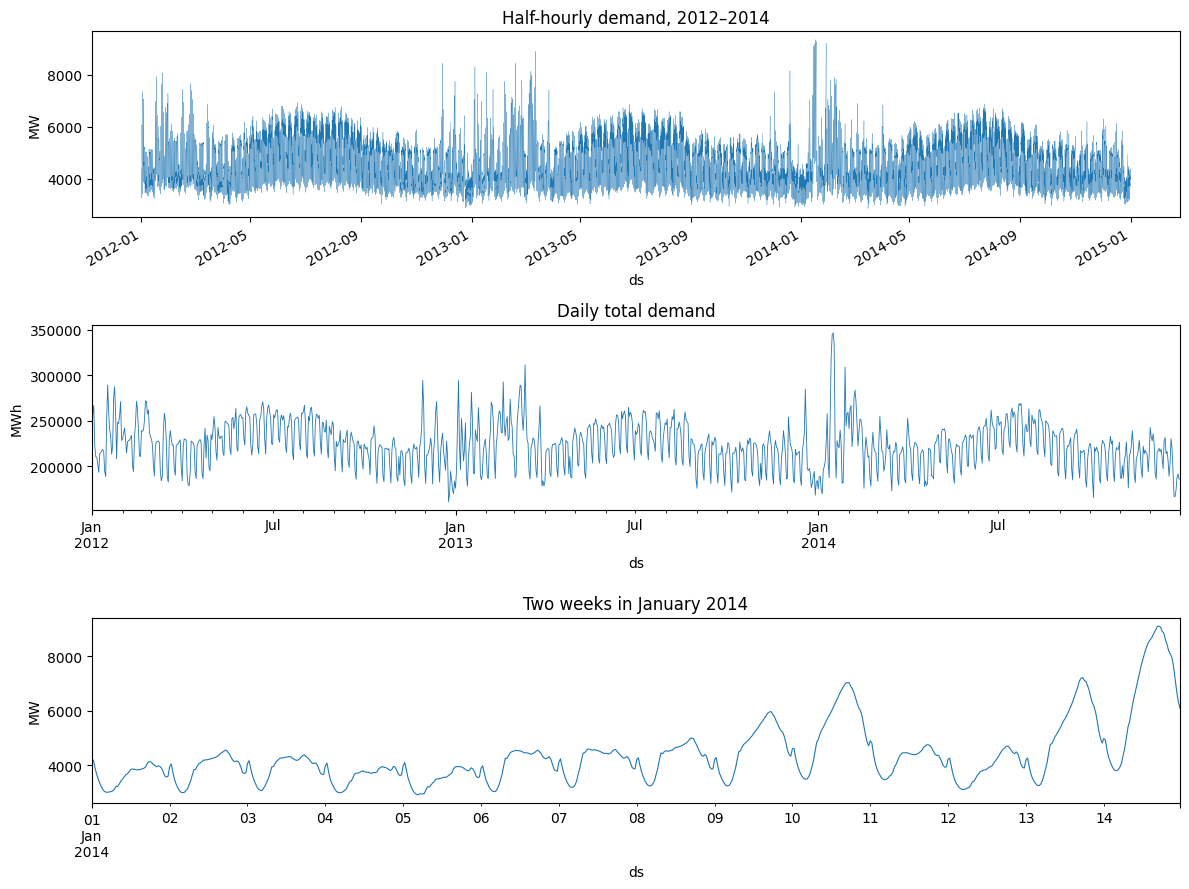

In [35]:
vic_elec_demand = (
        pd.read_csv('sample_data/vic_elec.csv', parse_dates=['ds'])
          .loc[lambda x: x['unique_id'] == 'Demand']
          .set_index('ds')['y']

        )


fig, axes = plt.subplots(3, 1, figsize=(12, 9))

# Half-hourly — too dense to read, which is the point
vic_elec_demand.plot(ax=axes[0], linewidth=0.2)
axes[0].set(title='Half-hourly demand, 2012–2014', ylabel='MW')

# Daily total
vic_elec_demand.resample('D').sum().plot(ax=axes[1], linewidth=0.6)
axes[1].set(title='Daily total demand', ylabel='MWh')

# One summer fortnight — reveals the daily cycle
vic_elec_demand['2014-01-01':'2014-01-14'].plot(ax=axes[2], linewidth=0.8)
axes[2].set(title='Two weeks in January 2014', ylabel='MW')

plt.tight_layout()
plt.show()

lambda = 0.950


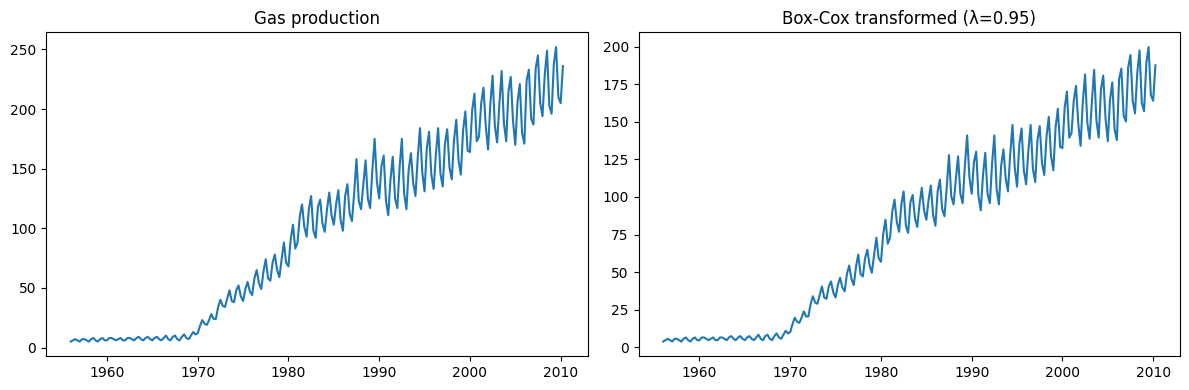

In [36]:
from scipy.stats import boxcox, boxcox_normmax
gas_prod = (
        pd.read_csv('sample_data/aus_production.csv', parse_dates=['ds'])
        )
lam = boxcox_normmax(gas_prod['Gas'])
print(f"lambda = {lam:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(gas_prod['ds'], gas_prod['Gas'])
axes[0].set(title='Gas production')
axes[1].plot(gas_prod['ds'], boxcox(gas_prod['Gas'], lam))
axes[1].set(title=f'Box-Cox transformed (λ={lam:.2f})')
plt.tight_layout()

lambda = 0.606


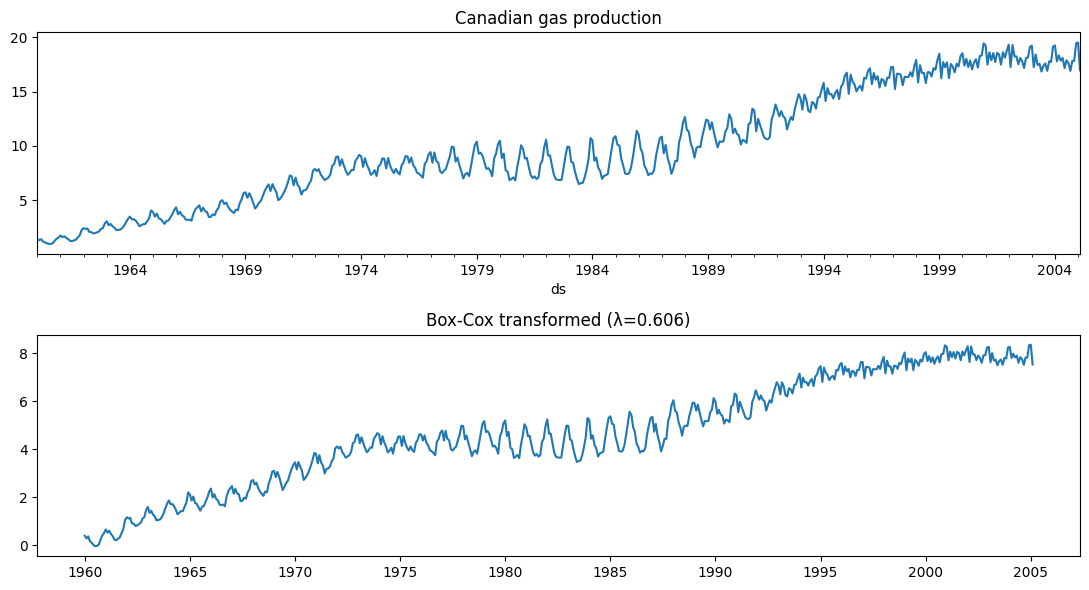

In [37]:
# Question 3.3
from scipy.stats import boxcox, boxcox_normmax
canada_gas = (
        pd.read_csv('sample_data/canadian_gas.csv', parse_dates=['ds'])
        .set_index('ds')['y']
        )

lam = boxcox_normmax(canada_gas)
print(f"lambda = {lam:.3f}")

fig, axes = plt.subplots(2, 1, figsize=(11, 6))
canada_gas.plot(ax=axes[0], title='Canadian gas production')
axes[1].plot(canada_gas.index, boxcox(canada_gas.values, lam))
axes[1].set(title=f'Box-Cox transformed (λ={lam:.3f})')
plt.tight_layout()

# A Box-Cox transformation is unhelpful here because the seasonal variation is not a monotonic function of the series level.

lambda = 0.2115


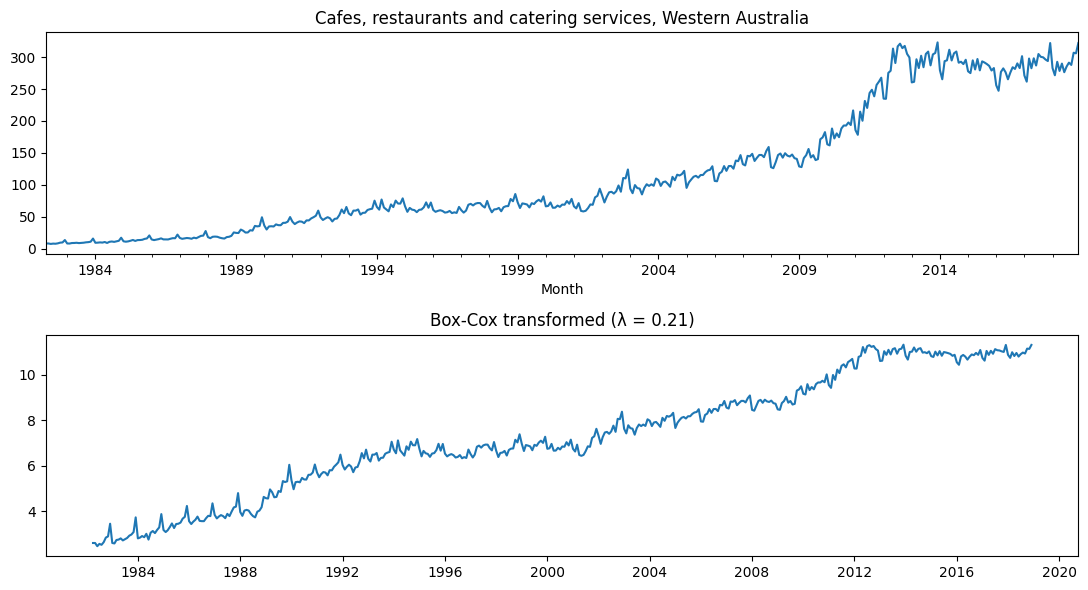

In [38]:
# Question 3.4

aus_retail = (
        pd.read_csv('sample_data/aus_retail.csv', parse_dates=['Month'])
        )

random = np.random.RandomState(12345678)
random_series_id = random.choice(aus_retail["Series ID"].unique())
myseries = aus_retail.loc[aus_retail["Series ID"] == random_series_id]

y = myseries.set_index('Month')['Turnover']

lam = boxcox_normmax(y.values)
print(f"lambda = {lam:.4f}")

fig, axes = plt.subplots(2, 1, figsize=(11, 6))
y.plot(ax=axes[0], title=f'{myseries["Industry"].iloc[0]}, {myseries["State"].iloc[0]}')
axes[1].plot(y.index, boxcox(y.values, lam))
axes[1].set(title=f'Box-Cox transformed (λ = {lam:.2f})')
plt.tight_layout()
plt.show()

# Maximum-likelihood estimation gives λ ≈ 0.21. Since this is close to zero, a log transformation (λ = 0) is preferable here.

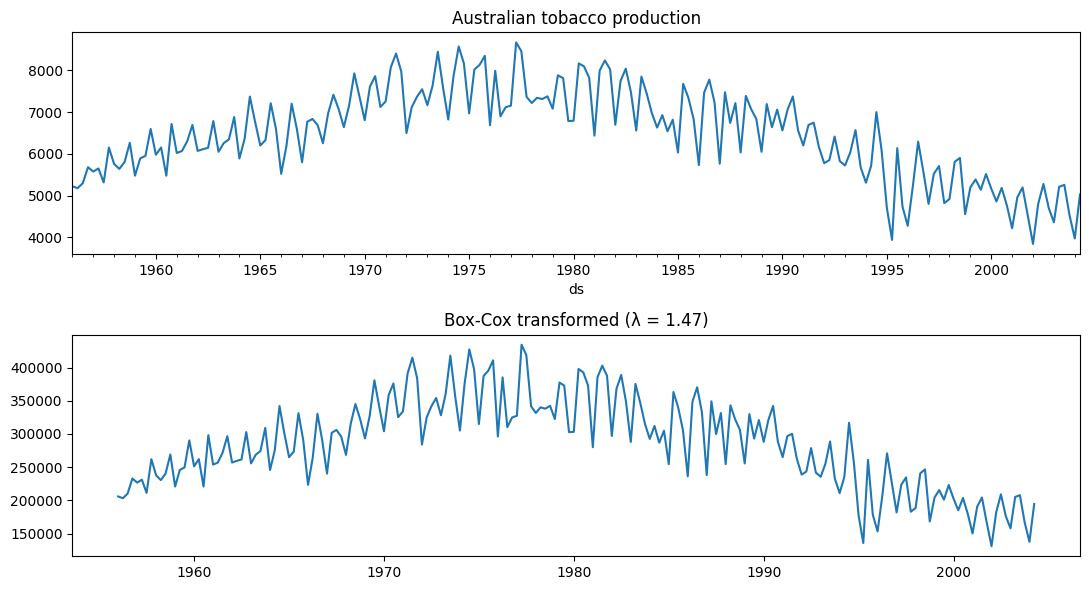

In [39]:
# Question 3.5
# For the following series, find an appropriate Box-Cox transformation to
# stabilise the variance: Tobacco from aus_production, Economy class passengers
# between Melbourne and Sydney from ansett, and Pedestrian counts at Southern Cross Station from pedestrian.

from scipy.stats import boxcox, boxcox_normmax

def find_lambda(y, title):
    lam = boxcox_normmax(y.values)
    fig, axes = plt.subplots(2, 1, figsize=(11, 6))
    y.plot(ax=axes[0], title=title)
    axes[1].plot(y.index, boxcox(y.values, lam))
    axes[1].set(title=f'Box-Cox transformed (λ = {lam:.2f})')
    plt.tight_layout()
    plt.show()
    return lam

aus_tobacco = (
        pd.read_csv('sample_data/aus_production.csv', parse_dates=['ds'])
        ).set_index('ds')['Tobacco'].dropna()
lam_tobacco = find_lambda(aus_tobacco, 'Australian tobacco production')

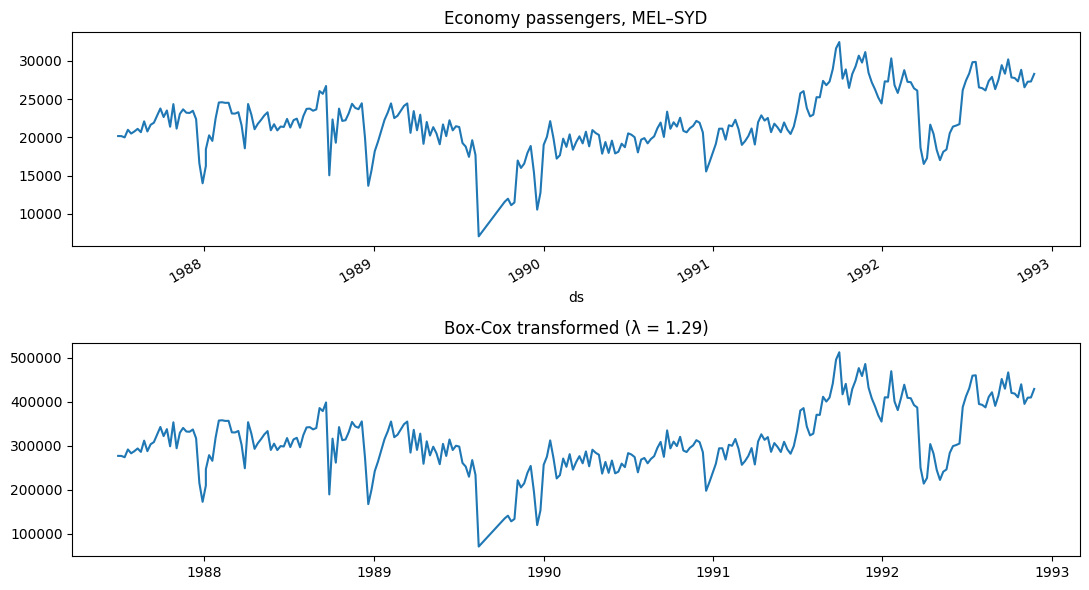

np.float64(1.2900813038568535)

In [40]:
ansett = pd.read_csv('sample_data/ansett.csv', parse_dates=['ds'])
mel_syd = (
    ansett.loc[(ansett['Airports'] == 'MEL-SYD') & (ansett['Class'] == 'Economy')]
          .set_index('ds')['y']
)
mel_syd_nz = mel_syd[mel_syd > 0]
find_lambda(mel_syd_nz, 'Economy passengers, MEL–SYD')    # λ ≈ 1.29

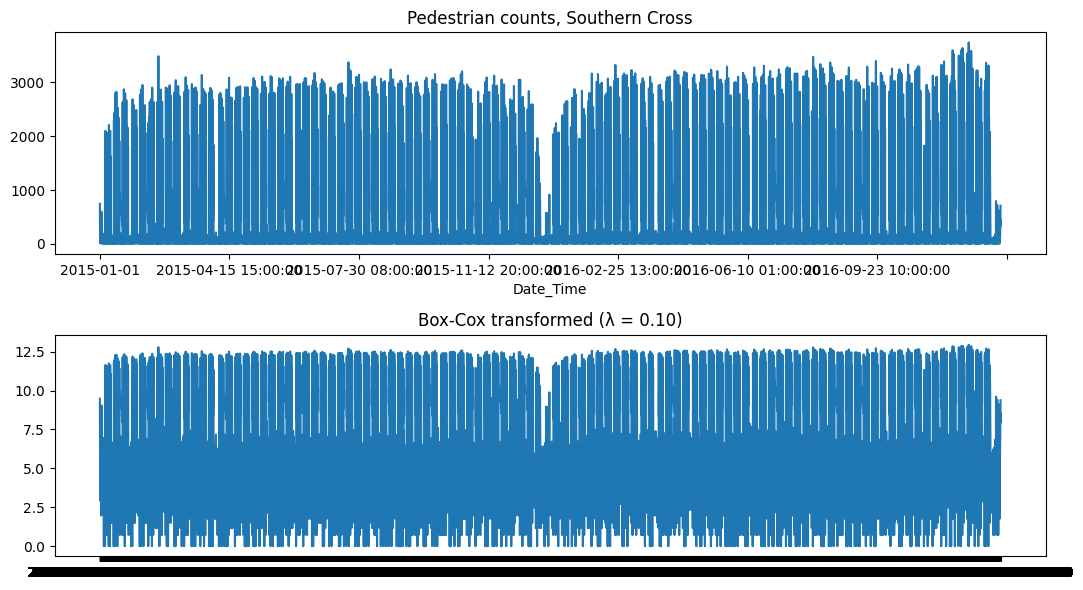

np.float64(0.10293906908881918)

In [48]:
# pedestrian = pd.read_csv('sample_data/pedestrian.csv', parse_dates=['Date_Time'])
# pedestrian.head()

sx = (
    pd.read_csv('sample_data/pedestrian.csv', parse_dates=['Date_Time'])
      .loc[lambda x: x['unique_id'] == 'Southern Cross Station']
              .set_index('Date_Time')['y']
)
sx_nz = sx[sx > 0]

find_lambda(sx_nz, 'Pedestrian counts, Southern Cross')   # λ ≈ 0.10

# Tobacco: λ ≈ 1.47 — no transformation. λ above 1 means variance isn't growing with the level.
# λ = 1 is already "no transformation," and 1.47 isn't far enough off to justify one.

# Ansett MEL–SYD: λ ≈ 1.29 — no transformation. Seven zeros between 21 Aug and 2 Oct 1989 (the pilots' strike)
# must be removed first, since Box-Cox needs strictly positive values. Yeo-Johnson gives λ ≈ 1.27 and the same conclusion.

# Southern Cross: λ ≈ 0.10 — use log (λ = 0). The only one that genuinely needs transforming.
# Hourly counts range from 0 to several thousand with variance clearly scaling with the level,
# and log is easier to interpret since differences become percentage changes.

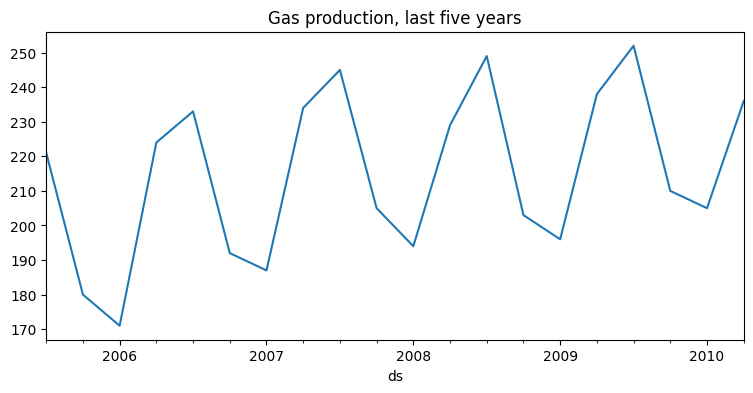

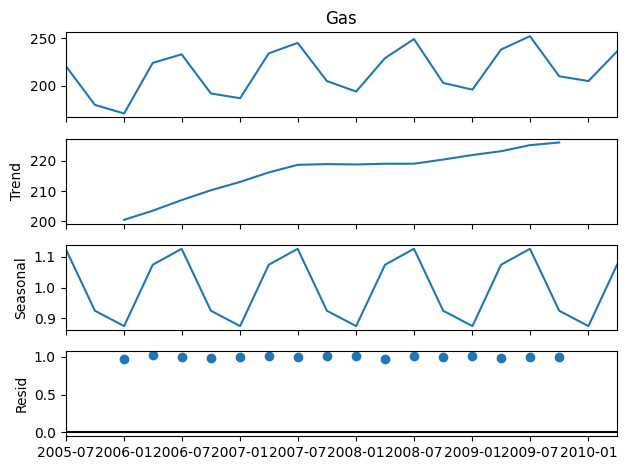

ds
2005-07-01    1.125681
2005-10-01    0.925066
2006-01-01    0.875282
2006-04-01    1.073971
Freq: QS-JAN, Name: seasonal, dtype: float64


In [52]:
# Question 3.6
# Consider the last five years of the Gas data from aus_production.
# Plot the time series. Use seasonal_decompose (multiplicative) to calculate trend-cycle and seasonal indices.
# Compute and plot seasonally adjusted data. Add an outlier and recompute.

gas_prod = (
        pd.read_csv('sample_data/aus_production.csv', parse_dates=['ds'])
        .set_index('ds')['Gas'].dropna()
        )
gas_prod.index.freq = 'QS'
gas_prod5 = gas_prod.tail(20)   # last five years

gas_prod5.plot(figsize=(9,4), title = 'Gas production, last five years')
plt.show()

decomp = seasonal_decompose(gas_prod5, model='multiplicative')
decomp.plot()
plt.show()

print(decomp.seasonal.head(4))

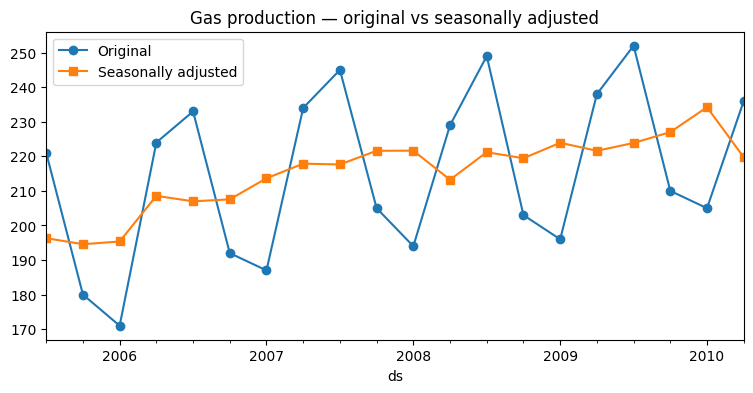

In [54]:
seas_adj = gas_prod5 / decomp.seasonal

fig, ax = plt.subplots(figsize=(9, 4))
gas_prod5.plot(ax=ax, label='Original', marker='o')
seas_adj.plot(ax=ax, label='Seasonally adjusted', marker='s')
ax.legend()
ax.set(title='Gas production — original vs seasonally adjusted')
plt.show()

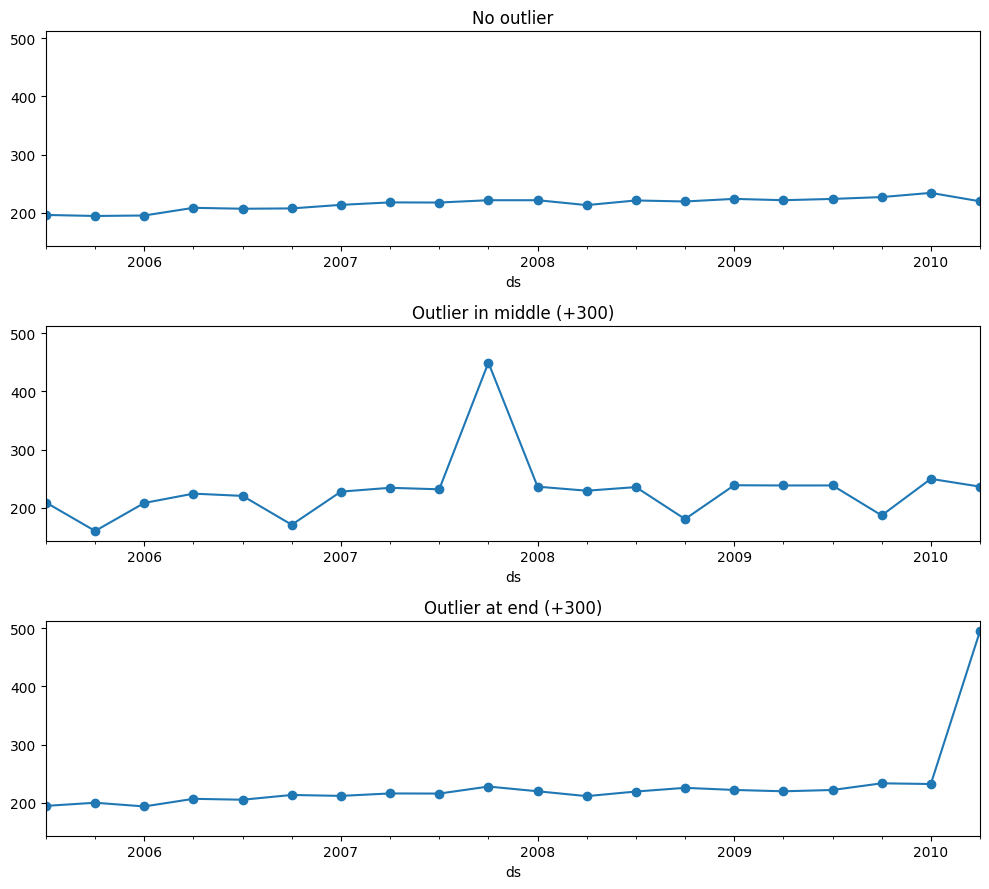

In [55]:
# Outlier in the middle
gas_mid = gas_prod5.copy()
gas_mid.iloc[9] += 300

d_mid = seasonal_decompose(gas_mid, model='multiplicative')
adj_mid = gas_mid / d_mid.seasonal

# Outlier at the end
gas_end = gas_prod5.copy()
gas_end.iloc[-1] += 300

d_end = seasonal_decompose(gas_end, model='multiplicative')
adj_end = gas_end / d_end.seasonal

fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharey=True)
for ax, (s, title) in zip(axes, [
    (seas_adj, 'No outlier'),
    (adj_mid, 'Outlier in middle (+300)'),
    (adj_end, 'Outlier at end (+300)'),
]):
    s.plot(ax=ax, marker='o', title=title)
plt.tight_layout()
plt.show()

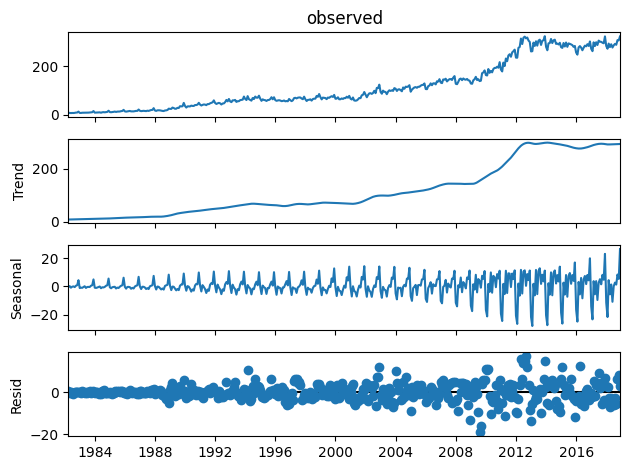

Month
2009-08-01   -4.45
2012-09-01    4.05
2009-09-01   -3.71
2012-05-01    3.65
2012-08-01    3.49
2013-12-01    3.44
2013-01-01   -3.23
2012-07-01    3.21
2008-12-01   -3.05
Name: resid, dtype: float64


In [60]:
# Question 3.7
# Decompose your retail time series using the MSTL method. Does it reveal any outliers or unusual features?
from statsmodels.tsa.seasonal import MSTL

aus_retail = (
        pd.read_csv('sample_data/aus_retail.csv', parse_dates=['Month'])
        )

random = np.random.RandomState(12345678)
random_series_id = random.choice(aus_retail["Series ID"].unique())
myseries = aus_retail.loc[aus_retail["Series ID"] == random_series_id]

y = myseries.set_index('Month')['Turnover']
y.index.freq = 'MS'

mstl_retail = MSTL(y, periods=(12,)).fit()
mstl_retail.plot()
plt.show()

# Flag outliers in the remainder
r = mstl_retail.resid
z = (r - r.mean()) / r.std()
print(z[abs(z) > 3].sort_values(key=abs, ascending=False).round(2))


## Answer:
MSTL flags nine residuals beyond three standard deviations, and they cluster rather than scatter. Late 2008 to late 2009 is all negative which is the financial crisis, with WA cafe turnover falling below what trend and seasonality predicted. 2012 is all positive, matching the peak of the mining boom. Clustered residuals like these point to real events the model doesn't account for, not random noise.

The seasonal pattern also grows a lot. The December effect rises from about +4 in 1982 to +26 in 2018. MSTL picks this up because its seasonal component can change over time; classical decomposition would have forced one fixed December value across all 36 years.


# Question 3.8
Write about 3-5 sentences describing the results of the decomposition for the persons in the civilian labour force in Australia (Figures 3.15 and 3.16). Is the recession of 1991/1992 visible?

**Answer: **

The trend dominates climbs steadily from about 6,500 to 9,000 thousand persons. The scales make that clear: the trend panel spans roughly 2,500 units while the seasonal and remainder panels cover only a few hundred, so both are small next to the overall growth. The seasonal pattern also shifts over time. September rises from about -18 to + 95 across the period, December grows, and March gets increasingly erratic.

The 1991/92 recession shows up clearly, mostly in the remainder. It sits within ±50 for most of the series, then drops to −190 in 1991 and rebounds to +115 within months. The trend barely flinches, it just plateaus — because the smoother is too rigid to absorb a downturn that sharp, so the signal ends up in the remainder instead.


In [ ]:
# Question 4.1
# Write a function to compute the mean and standard deviation of a time series and apply it to the PBS data.
# Plot the series with the highest mean and the series with the lowest standard deviation.



## Grading Rubric
- **Correctness (40%)**: Does the code run and produce the expected output?
- **Code Quality (30%)**: Is the code clean, commented, and efficient?
- **Analysis (30%)**: Are the interpretations and explanations clear and accurate?